Found 738 images belonging to 2 classes.
Found 183 images belonging to 2 classes.


c:\Users\bkous\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\bkous\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 390ms/step - accuracy: 0.5510 - loss: 1.2419 - val_accuracy: 0.6066 - val_loss: 0.6682
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.6225 - loss: 0.6828 - val_accuracy: 0.6066 - val_loss: 0.6523
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 183ms/step - accuracy: 0.6553 - loss: 0.6256 - val_accuracy: 0.6230 - val_loss: 0.6032
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 184ms/step - accuracy: 0.7640 - loss: 0.5108 - val_accuracy: 0.6612 - val_loss: 0.5373
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy: 0.8366 - loss: 0.4079 - val_accuracy: 0.6612 - val_loss: 0.5783
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.8594 - loss: 0.3497 - val_accuracy: 0.6721 - val_loss: 0.6745
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - accuracy: 0.9083 - loss: 0.2477 - val_accuracy: 0.7213 - val_loss: 0.8587
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.9252 - loss: 0.1961 - val_accuracy: 0

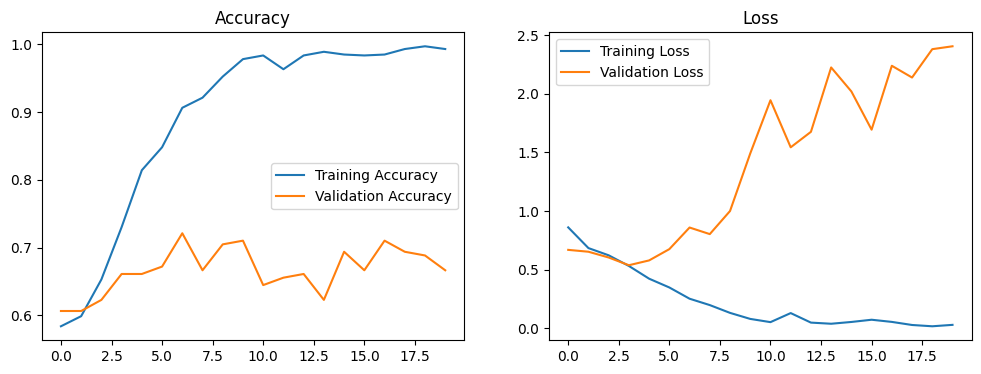

Found 921 images belonging to 2 classes.
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       362
           1       0.95      0.94      0.94       559

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921



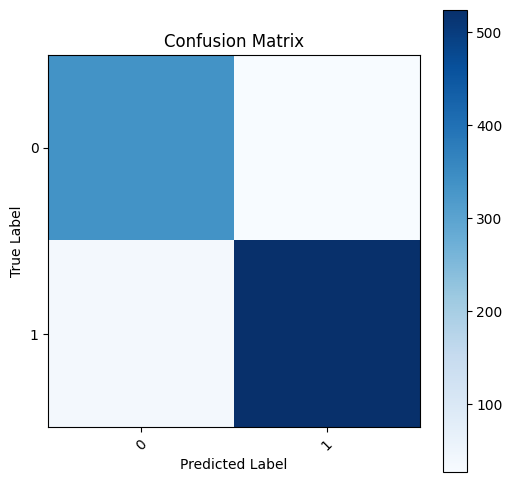

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os

# Step 1: Dataset Paths
dataset_dir = "dataset/ds"

# Image dimensions and batch size
IMG_HEIGHT, IMG_WIDTH = 224, 224  # All images will be resized to 224x224
BATCH_SIZE = 16

# Step 2: Data Splitting and Generators
# Using ImageDataGenerator to preprocess and split the data
data_gen = ImageDataGenerator(
    rescale=1.0 / 255.0,        # Normalize pixel values
    validation_split=0.2        # Split 80% training, 20% validation
)

# Training data generator with resizing
train_generator = data_gen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # Resize all images to 224x224
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'         # Use the training subset
)

# Validation data generator with resizing
validation_generator = data_gen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # Resize all images to 224x224
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'       # Use the validation subset
)

# Step 3: Model Creation
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Step 4: Model Compilation
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 5: Model Training
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,  # You can increase the number of epochs for better training
    verbose=1
)

# Step 6: Model Evaluation
# Evaluate on the validation dataset
val_loss, val_accuracy = model.evaluate(validation_generator, verbose=1)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

# Step 7: Visualize Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

# Step 8: Test the Model
# Test data generator with resizing
test_gen = ImageDataGenerator(rescale=1.0 / 255.0)
test_generator = test_gen.flow_from_directory(
    dataset_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),  # Resize all test images to 224x224
    batch_size=1,
    class_mode='binary',
    shuffle=False  # For consistent predictions
)

# Make predictions
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int)

# Classification report and confusion matrix
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(class_labels)), class_labels, rotation=45)
plt.yticks(range(len(class_labels)), class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 9: Save the Model
model.save("human_detection_model.h5")

In [2]:
!pip install --upgrade Pillow


     --------------------------------------- 13.8/13.8 MB 40.9 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.1.0
    Uninstalling pillow-11.1.0:
      Successfully uninstalled pillow-11.1.0


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\bkous\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~il\\_imaging.cp310-win_amd64.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.2.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Step 1: Load the saved model
model = load_model("human_detection_model.h5")
print("Model loaded successfully.")

# Step 2: Define the function to preprocess the image
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Preprocess the input image:
    1. Load the image from the given path.
    2. Resize it to the target size.
    3. Convert it to a numpy array and normalize pixel values.
    """
    img = load_img(image_path, target_size=target_size)  # Load and resize the image
    img_array = img_to_array(img)  # Convert the image to a numpy array
    img_array = img_array / 255.0  # Normalize pixel values to the range [0, 1]
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Step 3: Load and preprocess the test image
# Provide the path to the test image
test_image_path = "./dataset/ds/1/69.png"  # Replace with the path to your test image
preprocessed_image = preprocess_image(test_image_path)

# Step 4: Make a prediction
prediction = model.predict(preprocessed_image)
predicted_class = "human" if prediction > 0.5 else "not human"

# Step 5: Print the result
print(f"Prediction: {prediction[0][0]:.4f}")
print(f"The model predicts is: {predicted_class}")

Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: 0.9998
The model predicts is: human
